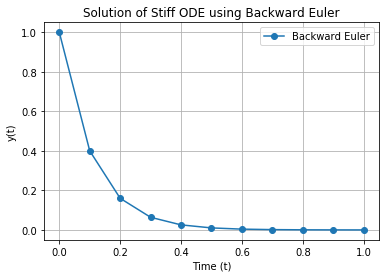

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Define the ODE
def f(t, y):
    return -15 * y

# Backward Euler method
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)      
    return t_values, y_values


# Parameters
y0 = 1
t0 = 0
tf = 1
h = 0.1

# Solve the ODE
t_values, y_values = backward_euler(f, y0, t0, tf, h)

# Plot the results
plt.plot(t_values, y_values, 'o-', label='Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

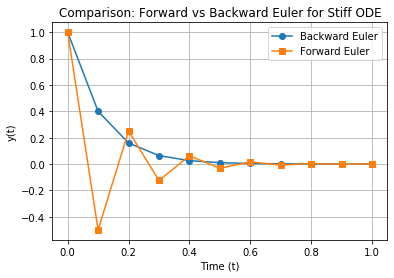

In [4]:
# Forward Euler method for comparison
def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        
    return t_values, y_values

# Solve using Forward Euler
t_values_fe, y_values_fe = forward_euler(f, y0, t0, tf, h)


# Plot comparison
plt.plot(t_values, y_values, 'o-', label='Backward Euler')
plt.plot(t_values_fe, y_values_fe, 's-', label='Forward Euler')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Comparison: Forward vs Backward Euler for Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()

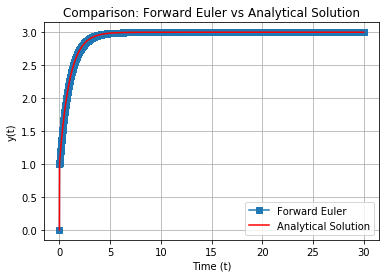

In [9]:
#In-Class Challenge 19:
def f(t, y):
    return (-1000 * y) + 3000 - 2000 * ((np.e)**(-t))

# Parameters
y0 = 0
t0 = 0
tf = 30
h = 0.001

# Solve the ODE
t_values, y_values = forward_euler(f, y0, t0, tf, h)

yAnalysis = 3 - 0.998 * (np.e**(-1000 * t_values)) - 2.002 * (np.e**(-(t_values)))

# Plot the results
plt.plot(t_values, y_values, 's-', label='Forward Euler')
plt.plot(t_values, yAnalysis, 'r-', label='Analytical Solution')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Comparison: Forward Euler vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#As the value of the step size h gets smaller and smaller, the cell either takes longer to run or does not run at all
#no matter what the h value is, a overflow error is returned
#Also, as h get smaller the graph begins to more closely resemble a logarithmic function